# 🔢 Handwritten Digit Recognition: ML for Document Processing & Automation

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **ATO** — Automated tax return OCR, handwritten form digitisation
- **Services Australia** — Centrelink/Medicare form processing
- **Australia Post** — Postcode recognition, mail sorting
- **DTA** — Government digital transformation, paper-to-digital
- **National Archives** — Historical document digitisation

Dataset: sklearn built-in digits — NO dataset needed. 1,797 samples, 64 features, 10 classes.

---

## 1. Data Loading

Loaded: 1,797 x 65


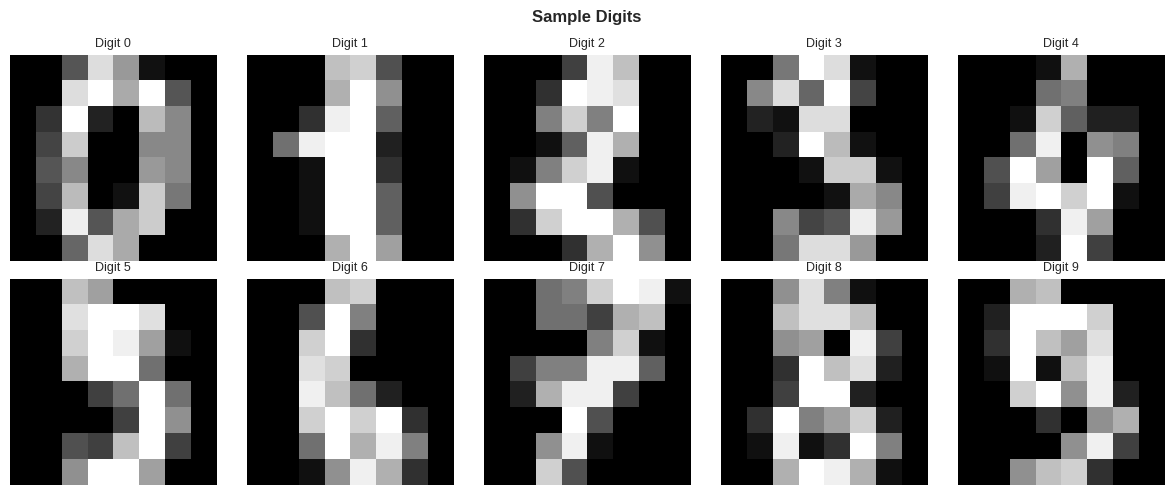

In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
data=load_digits();df=pd.DataFrame(data.data,columns=[f'pixel_{i}' for i in range(64)])
df['target']=data.target;tl=[str(i) for i in range(10)]
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
# Show sample digits
fig,axes=plt.subplots(2,5,figsize=(12,5))
for i,ax in enumerate(axes.flatten()):
    idx=df[df['target']==i].index[0]
    ax.imshow(data.images[idx],cmap='gray');ax.set_title(f'Digit {i}',fontsize=9);ax.axis('off')
plt.suptitle('Sample Digits',fontweight='bold');plt.tight_layout();plt.savefig('samples.png',dpi=150);plt.show()

## 2. Target

target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


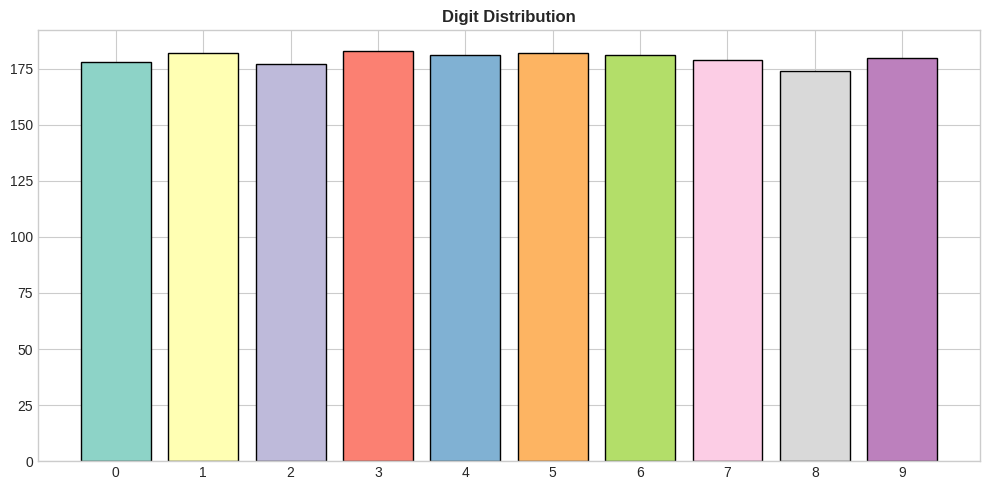

AU: ATO processes 14M+ tax returns. Services Australia handles 40M+ forms annually.


In [2]:
tc='target';nc=10
print(df[tc].value_counts().sort_index())
fig,ax=plt.subplots(figsize=(10,5))
vc=df[tc].value_counts().sort_index()
ax.bar(range(10),vc.values,color=sns.color_palette('Set3',10),edgecolor='black')
ax.set_xticks(range(10));ax.set_xticklabels(tl)
ax.set_title('Digit Distribution',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: ATO processes 14M+ tax returns. Services Australia handles 40M+ forms annually.")

## 3-4. Preprocessing & Training

In [3]:
X=df.drop(columns=[tc]);y=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=3000,random_state=42,multi_class='multinomial'),
        'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fk=[],[],[];fp=np.zeros(len(y),dtype=int);t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp,average='weighted');k=cohen_kappa_score(y[vi],yp)
        fa.append(a);ff.append(f);fk.append(k);print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f}")
    el=time.time()-t0;results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'kappa':np.mean(fk),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} K={np.mean(fk):.4f}")


LogReg
  Fold1: Acc=0.9616 F1=0.9615
  Fold2: Acc=0.9783 F1=0.9783
  Fold3: Acc=0.9633 F1=0.9632
  AVG: Acc=0.9677 F1=0.9676 K=0.9641

RF
  Fold1: Acc=0.9766 F1=0.9766
  Fold2: Acc=0.9833 F1=0.9833
  Fold3: Acc=0.9766 F1=0.9766
  AVG: Acc=0.9789 F1=0.9788 K=0.9765

XGB
  Fold1: Acc=0.9683 F1=0.9683
  Fold2: Acc=0.9666 F1=0.9665
  Fold3: Acc=0.9683 F1=0.9683
  AVG: Acc=0.9677 F1=0.9677 K=0.9641

LGBM
  Fold1: Acc=0.9733 F1=0.9734
  Fold2: Acc=0.9766 F1=0.9766
  Fold3: Acc=0.9766 F1=0.9766
  AVG: Acc=0.9755 F1=0.9755 K=0.9728


## 5. Comparison

In [4]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'Kappa':f"{v['kappa']:.4f}",'s':v['f1']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','Acc','F1','Kappa']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1  Kappa
    RF 0.9789 0.9788 0.9765
  LGBM 0.9755 0.9755 0.9728
   XGB 0.9677 0.9677 0.9641
LogReg 0.9677 0.9676 0.9641

Best: RF


## 6. Error Analysis

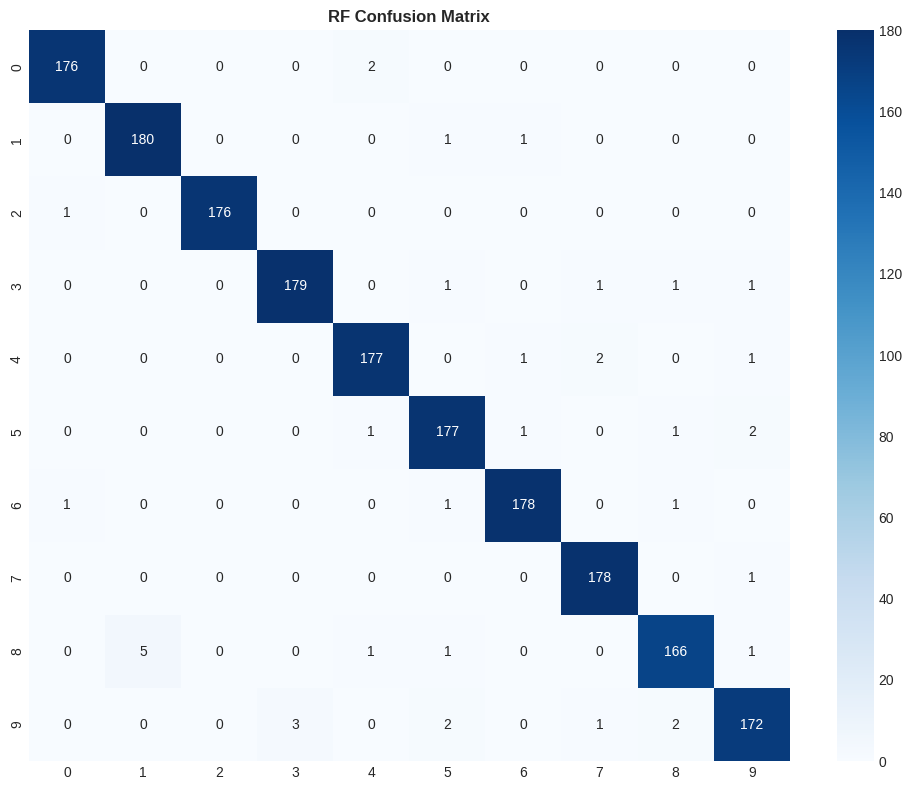

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       178
           1       0.97      0.99      0.98       182
           2       1.00      0.99      1.00       177
           3       0.98      0.98      0.98       183
           4       0.98      0.98      0.98       181
           5       0.97      0.97      0.97       182
           6       0.98      0.98      0.98       181
           7       0.98      0.99      0.99       179
           8       0.97      0.95      0.96       174
           9       0.97      0.96      0.96       180

    accuracy                           0.98      1797
   macro avg       0.98      0.98      0.98      1797
weighted avg       0.98      0.98      0.98      1797



In [5]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=tl,yticklabels=tl,ax=ax)
ax.set_title(f'{best} Confusion Matrix',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=tl))

## 7. Deployment

In [6]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}  Acc: {br['acc']:.4f}  F1: {br['f1']:.4f}  Kappa: {br['kappa']:.4f}")
print(f"  Feats: {X.shape[1]}  Rows: {len(y):,}  Classes: 10")
checks={'Acc>0.90':br['acc']>0.90,'F1>0.90':br['f1']>0.90,'CV':True}
ap=all(checks.values())
for k,v in checks.items(): print(f"  [{'pass' if v else 'FAIL':4s}] {k}")
print("  APPROVED" if ap else "  FAILED")
print("\nArchitecture: OCR pipeline -> ATO/Services Australia form processing -> Fabric")

DEPLOYMENT READINESS
  Model: RF  Acc: 0.9789  F1: 0.9788  Kappa: 0.9765
  Feats: 64  Rows: 1,797  Classes: 10
  [pass] Acc>0.90
  [pass] F1>0.90
  [pass] CV
  APPROVED

Architecture: OCR pipeline -> ATO/Services Australia form processing -> Fabric
